# Simple six-parameter Bayesian inference with NumPyro

This notebook uses the basic structure emphasized in Chapter 3 of *Bayes Rules!*:

\[
\text{posterior} \propto \text{likelihood}\times\text{prior}.
\]

For this detector problem:

1. **Prior:** bounded distributions for \(a_1,\ldots,a_6\).
2. **Data model:** the six-parameter spectrum is folded through the DRM.
3. **Likelihood:** the 200 detector values are modeled around that prediction.
4. **Posterior:** NumPyro's NUTS sampler draws \(a_1,\ldots,a_6\).

\[
s(E)=a_1e^{-a_2E}+a_3\exp\left[-\frac{(E-a_4)^2}{a_5E+a_6/E}\right].
\]

There is **no neural network** and **no training set**. `data_utils.py` generates one synthetic 200×1 vector, and NumPyro infers the six parameters from that vector.

## Install once

```bash
python -m pip install numpyro pandas matplotlib openpyxl
```

NumPyro uses JAX. Native Windows CPU support may work, but WSL is a practical fallback if JAX installation fails.

In [53]:
# Uncomment once if needed:
# %pip install numpyro pandas matplotlib openpyxl

## Imports and load `data_utils.py`

In [54]:
from pathlib import Path
import importlib.util
import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
from jax import random

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

jax.config.update("jax_enable_x64", True)


def load_data_utils():
    exact = Path("data_utils.py")
    if exact.exists():
        selected = exact
    else:
        candidates = sorted(Path.cwd().glob("data_utils*.py"))
        if len(candidates) == 0:
            raise FileNotFoundError("Place data_utils.py in the notebook directory.")
        if len(candidates) > 1:
            raise RuntimeError(
                "Multiple data_utils files found. Rename the intended one to data_utils.py: "
                + str([str(p) for p in candidates])
            )
        selected = candidates[0]

    spec = importlib.util.spec_from_file_location("data_utils_runtime", selected)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not import {selected}")

    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    print("Loaded:", selected.resolve())
    return module


du = load_data_utils()

if np.asarray(du.PFF_PARAM_SAMPLING).shape != (6, 4):
    raise ValueError("PFF_PARAM_SAMPLING must have shape (6, 4).")

print("JAX devices:", jax.devices())
print("NumPyro:", numpyro.__version__)

Loaded: C:\Users\aayan\OneDrive\Documents\GitHub\SAS-Analysis-Laser\data_utils.py
JAX devices: [CpuDevice(id=0)]
NumPyro: 0.21.0


## Configuration

In [55]:
DRM_XLSX_PATH = Path("res/drm/200x200.xlsx")
NUM_ENERGY_BINS = 50
SEED = 42

# Generate a bump-present example so all six parameters affect the data.
BUMP_FRACTION = .8

signature = inspect.signature(du.generate_spectrum_batch)
NOISE_GAIN = float(signature.parameters["noise_gain"].default)
READ_FRAC = float(signature.parameters["read_frac"].default)
MULT_FRAC = float(signature.parameters["mult_frac"].default)

# Kept off because the simple likelihood below does not model clipping.
SAT_FRACTION = 0.05

NUM_WARMUP = 1000
NUM_SAMPLES = 2000
NUM_CHAINS = 4

print("Noise settings:", NOISE_GAIN, READ_FRAC, MULT_FRAC)

Noise settings: 5.0 0.02 0.01


## Load and bin the DRM

In [56]:
drm = du.load_drm(str(DRM_XLSX_PATH))
drm_binned = du.bin_drm(drm, NUM_ENERGY_BINS).astype(np.float64)
energy_bins = du.mev_bin_centers(NUM_ENERGY_BINS).astype(np.float64)

print("DRM:", drm.shape)
print("Binned DRM:", drm_binned.shape)
print("Energy bins:", energy_bins.shape)

DRM: (200, 200)
Binned DRM: (200, 50)
Energy bins: (50,)


Spectra shape: (50, 50)
Parameter shape: (50, 6)
Clean signal shape: (50, 200)


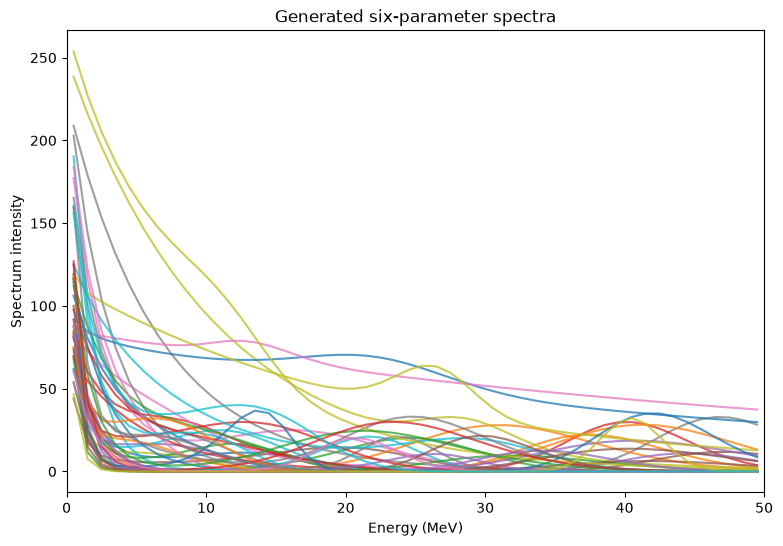

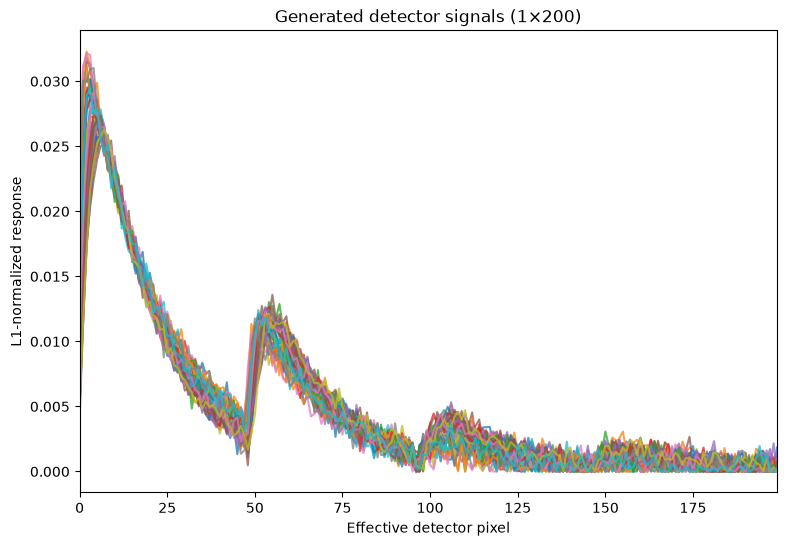

In [57]:
# ================================================================
# Plot generated spectra and corresponding 200-channel signals
# ================================================================

N_PLOT_SAMPLES = 50
PLOT_SEED = 123

plot_rng = np.random.default_rng(
    PLOT_SEED
)

# ------------------------------------------------
# 1. Generate six-parameter spectra and parameters
# ------------------------------------------------

generated_spectra, generated_parameters = (
    du.sample_pff_spectra(
        n_samples=N_PLOT_SAMPLES,
        energy_bins=energy_bins,
        rng=plot_rng,
        bump_fraction=1.0,  # every example has a bump
    )
)

print(
    "Spectra shape:",
    generated_spectra.shape,
)
# Expected: (50, 50)

print(
    "Parameter shape:",
    generated_parameters.shape,
)
# Expected: (50, 6)


# ------------------------------------------------
# 2. Fold spectra through the DRM
# ------------------------------------------------

clean_signals = (
    drm_binned
    @ generated_spectra.T
).T

print(
    "Clean signal shape:",
    clean_signals.shape,
)
# Expected: (50, 200)


# ------------------------------------------------
# 3. Apply data_utils detector noise
# ------------------------------------------------

noisy_signals = du.add_detector_noise(
    clean_signals,
    plot_rng,
    noise_gain=NOISE_GAIN,
    read_frac=READ_FRAC,
    mult_frac=MULT_FRAC,
)


# Optional saturation augmentation.
# Keep this at 0.0 for the simplest graph.
PLOT_SAT_FRACTION = 0.0

noisy_signals, _ = du.apply_saturation(
    noisy_signals,
    plot_rng,
    sat_fraction=PLOT_SAT_FRACTION,
    ceil_low=du.SAT_CEIL_LOW,
    ceil_high=du.SAT_CEIL_HIGH,
)


# ------------------------------------------------
# 4. Normalize signals to sum to one
# ------------------------------------------------

signals_l1 = (
    noisy_signals
    / np.maximum(
        noisy_signals.sum(
            axis=1,
            keepdims=True,
        ),
        1e-12,
    )
)


# ------------------------------------------------
# Graph 1: generated spectra
# ------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

for index in range(
    N_PLOT_SAMPLES
):
    plt.plot(
        energy_bins,
        generated_spectra[index],
        alpha=0.75,
    )

plt.title(
    "Generated six-parameter spectra"
)

plt.xlabel(
    "Energy (MeV)"
)

plt.ylabel(
    "Spectrum intensity"
)

plt.xlim(
    0,
    50,
)

plt.show()


# ------------------------------------------------
# Graph 2: corresponding detector signals
# ------------------------------------------------

detector_channels = np.arange(
    200
)

plt.figure(
    figsize=(9, 6)
)

for index in range(
    N_PLOT_SAMPLES
):
    plt.plot(
        detector_channels,
        signals_l1[index],
        alpha=0.75,
    )

plt.title(
    "Generated detector signals (1×200)"
)

plt.xlabel(
    "Effective detector pixel"
)

plt.ylabel(
    "L1-normalized response"
)

plt.xlim(
    0,
    199,
)

plt.show()

## Generate one synthetic 200×1 observation

The vector remains in raw detector units. It is not L1-normalized, because that would remove information about the common amplitude scale of \(a_1\) and \(a_3\).

Input shape: (200, 1)


,parameter,true_value
0,a1,180.471708
1,a2,1.427241
2,a3,0.000000
3,a4,43.514118
4,a5,1.379398
5,a6,488.895968


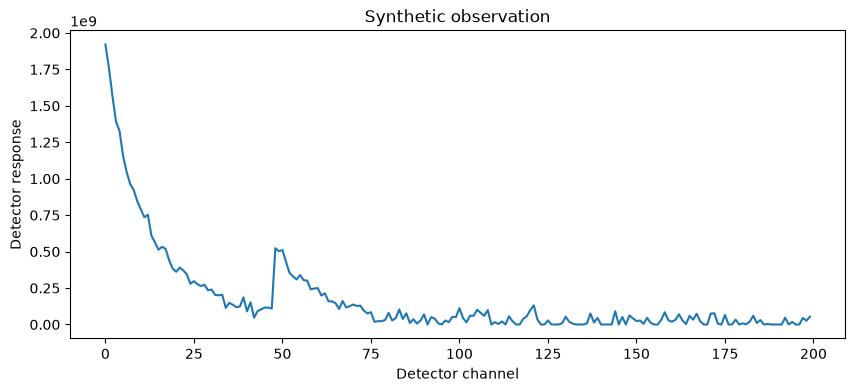

In [58]:
rng = np.random.default_rng(SEED)

spectra, parameters = du.sample_pff_spectra(
    n_samples=1,
    energy_bins=energy_bins,
    rng=rng,
    bump_fraction=BUMP_FRACTION,
)

true_spectrum = spectra[0]
true_parameters = parameters[0]

clean_detector = drm_binned @ true_spectrum
observed_vector = du.add_detector_noise(
    clean_detector[None, :],
    rng,
    noise_gain=NOISE_GAIN,
    read_frac=READ_FRAC,
    mult_frac=MULT_FRAC,
)[0]

observed_vector_200x1 = observed_vector.reshape(200, 1)
print("Input shape:", observed_vector_200x1.shape)

display(pd.DataFrame({
    "parameter": ["a1", "a2", "a3", "a4", "a5", "a6"],
    "true_value": true_parameters,
}))

plt.figure(figsize=(10, 4))
plt.plot(observed_vector)
plt.xlabel("Detector channel")
plt.ylabel("Detector response")
plt.title("Synthetic observation")
plt.show()

## Prior, likelihood, and posterior

- **Prior:** each parameter uses the bounded-normal mean, standard deviation, and limits from `PFF_PARAM_SAMPLING`.
- **Forward model:** \(\mu(\theta)=D\,s(\theta)\).
- **Likelihood:** each detector channel is Gaussian around \(\mu_i\), using the same variance formula as `data_utils.py`.
- **Posterior:** because this model is nonlinear and non-conjugate, NUTS samples the posterior numerically.

In [59]:
parameter_sampling = np.asarray(du.PFF_PARAM_SAMPLING, dtype=np.float64)

display(pd.DataFrame(
    parameter_sampling,
    index=["a1", "a2", "a3", "a4", "a5", "a6"],
    columns=["mean", "std", "low", "high"],
))

drm_jax = jnp.asarray(drm_binned)
energy_jax = jnp.asarray(energy_bins)
prior_mean = jnp.asarray(parameter_sampling[:, 0])
prior_std = jnp.asarray(parameter_sampling[:, 1])
prior_low = jnp.asarray(parameter_sampling[:, 2])
prior_high = jnp.asarray(parameter_sampling[:, 3])
a3_bump_low = max(5.0, float(parameter_sampling[2, 2]))


def pff6(a1, a2, a3, a4, a5, a6):
    E = jnp.maximum(energy_jax, 1e-12)
    denominator = jnp.maximum(a5 * E + a6 / E, 1e-12)
    return (
        a1 * jnp.exp(-a2 * E)
        + a3 * jnp.exp(-((E - a4) ** 2) / denominator)
    )


def bayesian_model(detector_observation=None):
    # 1. Prior model
    a1 = numpyro.sample("a1", dist.TruncatedNormal(
        prior_mean[0], prior_std[0], low=prior_low[0], high=prior_high[0]
    ))
    a2 = numpyro.sample("a2", dist.TruncatedNormal(
        prior_mean[1], prior_std[1], low=prior_low[1], high=prior_high[1]
    ))
    a3 = numpyro.sample("a3", dist.TruncatedNormal(
        prior_mean[2], prior_std[2], low=a3_bump_low, high=prior_high[2]
    ))
    a4 = numpyro.sample("a4", dist.TruncatedNormal(
        prior_mean[3], prior_std[3], low=prior_low[3], high=prior_high[3]
    ))
    a5 = numpyro.sample("a5", dist.TruncatedNormal(
        prior_mean[4], prior_std[4], low=prior_low[4], high=prior_high[4]
    ))
    a6 = numpyro.sample("a6", dist.TruncatedNormal(
        prior_mean[5], prior_std[5], low=prior_low[5], high=prior_high[5]
    ))

    # 2. Physical forward model
    spectrum = pff6(a1, a2, a3, a4, a5, a6)
    predicted = jnp.maximum(drm_jax @ spectrum, 1e-12)

    # 3. Likelihood noise model
    peak = jnp.max(predicted)
    variance = (
        NOISE_GAIN * predicted
        + (READ_FRAC * peak) ** 2
        + (MULT_FRAC * predicted) ** 2
    )
    sigma = jnp.sqrt(jnp.maximum(variance, 1e-12))

    numpyro.sample(
        "obs",
        dist.Normal(predicted, sigma).to_event(1),
        obs=detector_observation,
    )

,mean,std,low,high
a1,150.0,100.0,50.000000,250.0
a2,0.3,1.0,0.010000,2.0
a3,20.0,10.0,0.000000,50.0
a4,20.0,25.0,1.000000,49.0
a5,0.5,1.0,0.000001,10.0
a6,100.0,500.0,0.000001,10000.0


## Run NUTS

In [60]:
observed_jax = jnp.asarray(observed_vector_200x1.reshape(200))

kernel = NUTS(
    bayesian_model,
    target_accept_prob=0.90,
    dense_mass=True,
)

mcmc = MCMC(
    kernel,
    num_warmup=NUM_WARMUP,
    num_samples=NUM_SAMPLES,
    num_chains=NUM_CHAINS,
    chain_method="sequential",
    progress_bar=True,
)

mcmc.run(
    random.key(SEED + 1),
    detector_observation=observed_jax,
)

mcmc.print_summary()
posterior_samples = mcmc.get_samples(group_by_chain=False)

sample: 100%|██████████| 3000/3000 [00:05<00:00, 526.95it/s, 63 steps of size 4.45e-02. acc. prob=0.94] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a1    187.40     20.60    188.20    154.24    221.27   2709.08      1.00
        a2      1.77      0.14      1.79      1.57      2.00   2323.45      1.00
        a3     11.37      6.05      9.39      5.00     20.04   1058.30      1.00
        a4      1.36      0.35      1.25      1.00      1.80   1409.95      1.00
        a5      0.24      0.21      0.18      0.00      0.53   3303.56      1.00
        a6      3.02      3.38      1.79      0.00      7.64   2987.99      1.00

Number of divergences: 109


## Posterior summaries and distributions

,parameter,true_value,posterior_mean,posterior_std,posterior_median,credible_2.5%,credible_97.5%
0,a1,180.471708,187.404939,20.600478,188.199791,146.406423,224.089021
1,a2,1.427241,1.771800,0.143918,1.785731,1.480459,1.990769
2,a3,0.000000,11.371170,6.052505,9.387302,5.148452,27.349403
3,a4,43.514118,1.359605,0.348751,1.250469,1.012202,2.249575
4,a5,1.379398,0.235789,0.208181,0.177249,0.007404,0.768488
5,a6,488.895968,3.017358,3.375398,1.787276,0.069466,12.450441


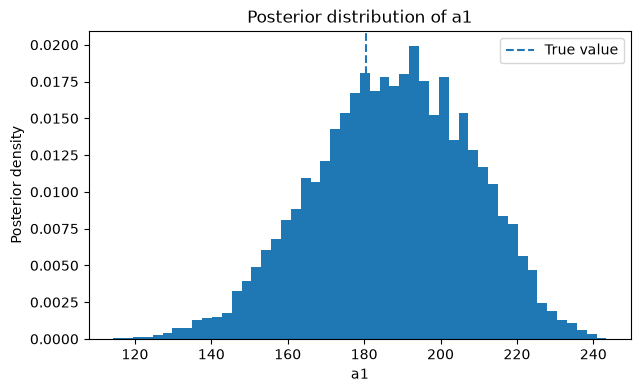

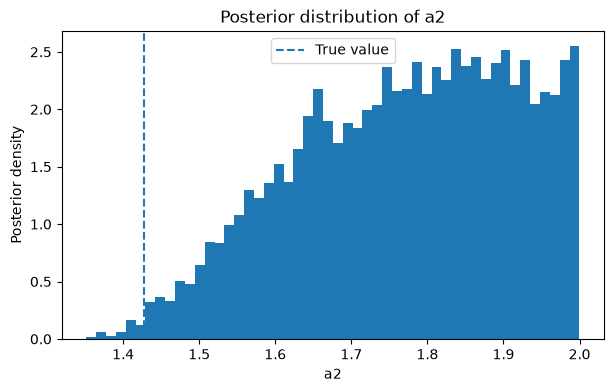

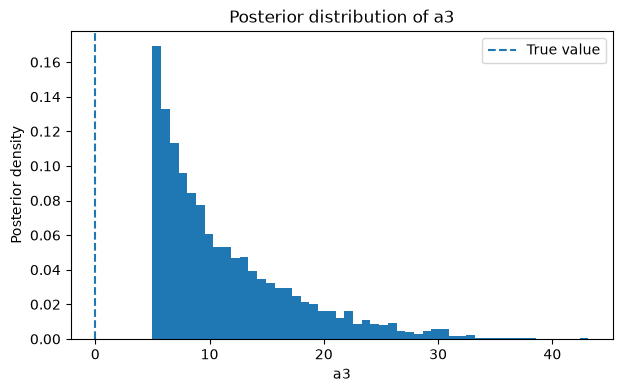

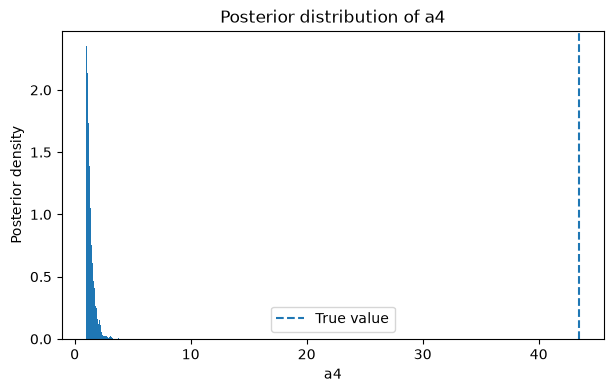

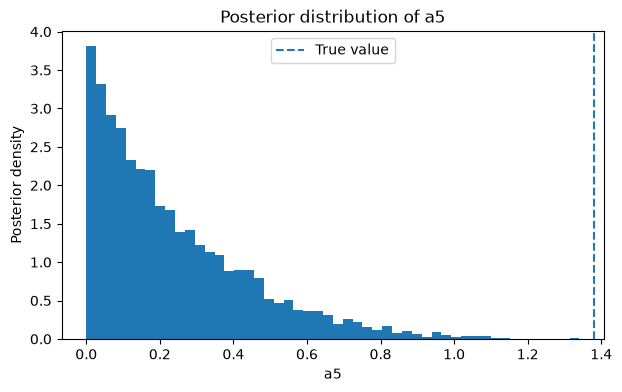

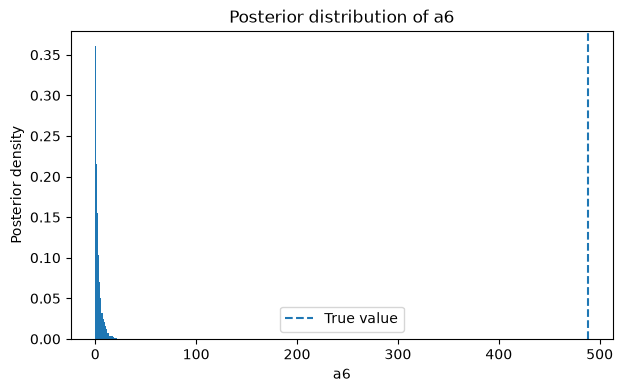

In [61]:
parameter_names = ["a1", "a2", "a3", "a4", "a5", "a6"]
rows = []

for i, name in enumerate(parameter_names):
    values = np.asarray(posterior_samples[name])
    rows.append({
        "parameter": name,
        "true_value": true_parameters[i],
        "posterior_mean": values.mean(),
        "posterior_std": values.std(),
        "posterior_median": np.median(values),
        "credible_2.5%": np.percentile(values, 2.5),
        "credible_97.5%": np.percentile(values, 97.5),
    })

posterior_summary = pd.DataFrame(rows)
display(posterior_summary)

for i, name in enumerate(parameter_names):
    values = np.asarray(posterior_samples[name])
    plt.figure(figsize=(7, 4))
    plt.hist(values, bins=50, density=True)
    plt.axvline(true_parameters[i], linestyle="--", label="True value")
    plt.xlabel(name)
    plt.ylabel("Posterior density")
    plt.title(f"Posterior distribution of {name}")
    plt.legend()
    plt.show()

## Posterior-predictive check

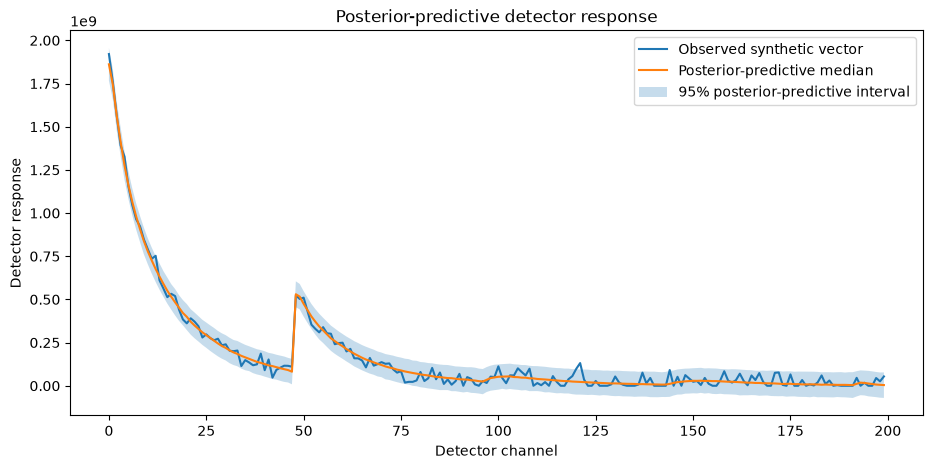

In [62]:
predictive = Predictive(
    bayesian_model,
    posterior_samples=posterior_samples,
    return_sites=["obs"],
)

posterior_predictive = predictive(
    random.key(SEED + 2),
    detector_observation=None,
)

predicted_vectors = np.asarray(posterior_predictive["obs"])
median = np.median(predicted_vectors, axis=0)
low = np.percentile(predicted_vectors, 2.5, axis=0)
high = np.percentile(predicted_vectors, 97.5, axis=0)

plt.figure(figsize=(11, 5))
plt.plot(observed_vector, label="Observed synthetic vector")
plt.plot(median, label="Posterior-predictive median")
plt.fill_between(
    np.arange(200), low, high, alpha=0.25,
    label="95% posterior-predictive interval",
)
plt.xlabel("Detector channel")
plt.ylabel("Detector response")
plt.title("Posterior-predictive detector response")
plt.legend()
plt.show()

## Save results

In [63]:
pd.DataFrame({
    name: np.asarray(posterior_samples[name])
    for name in parameter_names
}).to_csv("numpyro_6param_posterior_samples.csv", index=False)

posterior_summary.to_csv(
    "numpyro_6param_posterior_summary.csv",
    index=False,
)

np.savez(
    "numpyro_6param_results.npz",
    observed_vector=observed_vector,
    clean_detector=clean_detector,
    true_spectrum=true_spectrum,
    true_parameters=true_parameters,
    energy_bins=energy_bins,
    drm_binned=drm_binned,
    **{name: np.asarray(posterior_samples[name]) for name in parameter_names},
)

print("Saved posterior samples, summary, and NPZ results.")

Saved posterior samples, summary, and NPZ results.


## Later use with a real 200×1 vector

No neural-network retraining is needed. Replace `observed_vector_200x1` with a non-negative real array of shape `(200, 1)`, then rerun the NUTS and posterior cells.

The current simple likelihood assumes:

- the vector uses the same raw scale as the DRM prediction;
- it is not saturated;
- channel errors follow the configured Gaussian noise model.

If the real detector and DRM have different absolute scales, a positive detector-gain parameter should be added before interpreting the absolute values of \(a_1\) and \(a_3\).

## Why this follows Chapter 3 without using Beta-Binomial conjugacy

The Chapter 3 example has a Beta prior and Binomial data, so its posterior has a closed-form Beta distribution. Here, the unknowns are six continuous physical parameters and the data are 200 continuous detector measurements. The forward relationship is nonlinear, so the posterior is not available in a simple closed form. NumPyro's NUTS algorithm numerically draws from that posterior while preserving the same prior–likelihood–posterior logic.

## Real-shot inference

The following cell reads the same 200-channel shot CSV files used by
the prior CNN inference script. It runs a separate NumPyro NUTS
posterior for each shot and saves posterior tables and figures.

The real-shot likelihood compares L1-normalized detector shapes.
Consequently, the common absolute scale of `a1` and `a3` is weakly
identified; the detector shape constrains their relative
contribution more strongly.

In [64]:
# ============================================================================
# REAL-SHOT INFERENCE CELL
#
# Run the earlier notebook cells first so these objects already exist:
#   du, drm_binned, energy_bins, parameter_sampling,
#   prior_mean, prior_std, prior_low, prior_high,
#   jax, jnp, random, numpyro, dist, MCMC, NUTS,
#   np, pd, plt
#
# This cell:
#   - reads 200-channel *_proc_vector_ch.csv and *_proc_vector_cv.csv files
#   - L1-normalizes real and modeled detector responses
#   - runs a new NumPyro NUTS posterior for each shot
#   - ignores saturation-corrected channels in the likelihood when a mask exists
#   - saves posterior samples and parameter summaries
#   - saves detector/spectrum/residual and parameter-posterior figures
#
# Important:
#   Because the fit uses L1-normalized response shapes, the common absolute
#   amplitude scale of a1 and a3 is only weakly identified. Their ratio and the
#   shape parameters are better constrained than their common scale.
# ============================================================================

from pathlib import Path
import warnings


# ----------------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------------

SHOT_NUM_WARMUP = 750
SHOT_NUM_SAMPLES = 1_000
SHOT_NUM_CHAINS = 1
SHOT_TARGET_ACCEPT = 0.90
SHOT_MAX_PREDICTIVE_DRAWS = 1_000

# Robust likelihood for normalized detector shapes.
SHOT_STUDENT_T_DF = 4.0
SHOT_SIGMA_PRIOR_SCALE = 0.01

SHOT_RESULTS_DIR = Path(
    "numpyro_shot_results"
)
SHOT_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DEFAULT_SHOTS = [
    "res/test_images/10084/10084_proc_vector_ch.csv",
    "res/test_images/11674/11674_proc_vector_ch.csv",
    "res/test_images/11733/11733_proc_vector_ch.csv",
    "res/test_images/11705/11705_proc_vector_ch.csv",
    "res/test_images/11707/11707_proc_vector_ch.csv",
    "res/test_images/11716/11716_proc_vector_ch.csv",

    "res/test_images/10084/10084_proc_vector_cv.csv",
    "res/test_images/11674/11674_proc_vector_cv.csv",
    "res/test_images/11733/11733_proc_vector_cv.csv",
    "res/test_images/11705/11705_proc_vector_cv.csv",
    "res/test_images/11707/11707_proc_vector_cv.csv",
    "res/test_images/11716/11716_proc_vector_cv.csv",
]

# Replace this list to infer only selected shots.
SHOT_PATHS = DEFAULT_SHOTS


# ----------------------------------------------------------------------------
# Input helpers
# ----------------------------------------------------------------------------

def load_shot_signal(
    csv_path: str | Path,
) -> np.ndarray:
    """
    Load one 200-channel detector vector.

    This matches the earlier inference script by reading the final CSV column.
    """
    csv_path = Path(csv_path)

    dataframe = pd.read_csv(
        csv_path
    )

    signal = (
        dataframe.iloc[:, -1]
        .to_numpy(
            dtype=np.float64
        )
        .reshape(-1)
    )

    if signal.shape != (200,):
        raise ValueError(
            f"{csv_path}: expected 200 values, received {signal.shape}."
        )

    if not np.all(
        np.isfinite(signal)
    ):
        raise ValueError(
            f"{csv_path}: signal contains NaN or infinite values."
        )

    signal = np.clip(
        signal,
        0.0,
        None,
    )

    if signal.sum() <= 0.0:
        raise ValueError(
            f"{csv_path}: signal has no positive intensity."
        )

    return signal


def l1_normalize_vector(
    values: np.ndarray,
) -> np.ndarray:
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    return (
        values
        / max(
            float(values.sum()),
            1e-12,
        )
    )


def shot_labels(
    csv_path: str | Path,
) -> tuple[str, str, str]:
    path = Path(csv_path)
    stem = path.stem
    shot_name = stem.split("_")[0]

    final_token = stem.split("_")[-1]
    view_tag = (
        final_token
        if final_token in {"ch", "cv"}
        else ""
    )

    view_suffix = (
        f"_{view_tag}"
        if view_tag
        else ""
    )

    return shot_name, view_tag, view_suffix


# ----------------------------------------------------------------------------
# Real-shot Bayesian model
# ----------------------------------------------------------------------------

def shot_bayesian_model(
    detector_observation=None,
    valid_channel_mask=None,
):
    """
    Bayesian shape fit for one L1-normalized 200-channel detector vector.

    The forward model is the six-parameter PFF folded through the binned DRM.
    A Student-t likelihood makes the fit less sensitive to individual
    mismatched channels than a Gaussian likelihood.
    """

    # Priors from data_utils.PFF_PARAM_SAMPLING.
    a1 = numpyro.sample(
        "a1",
        dist.TruncatedNormal(
            prior_mean[0],
            prior_std[0],
            low=prior_low[0],
            high=prior_high[0],
        ),
    )

    a2 = numpyro.sample(
        "a2",
        dist.TruncatedNormal(
            prior_mean[1],
            prior_std[1],
            low=prior_low[1],
            high=prior_high[1],
        ),
    )

    # For real shots, permit a3 to approach zero.
    # This is continuous; it is not a discrete bump/no-bump mixture.
    a3 = numpyro.sample(
        "a3",
        dist.TruncatedNormal(
            prior_mean[2],
            prior_std[2],
            low=prior_low[2],
            high=prior_high[2],
        ),
    )

    a4 = numpyro.sample(
        "a4",
        dist.TruncatedNormal(
            prior_mean[3],
            prior_std[3],
            low=prior_low[3],
            high=prior_high[3],
        ),
    )

    a5 = numpyro.sample(
        "a5",
        dist.TruncatedNormal(
            prior_mean[4],
            prior_std[4],
            low=prior_low[4],
            high=prior_high[4],
        ),
    )

    a6 = numpyro.sample(
        "a6",
        dist.TruncatedNormal(
            prior_mean[5],
            prior_std[5],
            low=prior_low[5],
            high=prior_high[5],
        ),
    )

    sigma = numpyro.sample(
        "sigma",
        dist.HalfNormal(
            SHOT_SIGMA_PRIOR_SCALE
        ),
    )

    # Six-parameter spectrum.
    spectrum = pff6(
        a1,
        a2,
        a3,
        a4,
        a5,
        a6,
    )

    # Forward fold through the 200×50 DRM.
    predicted_raw = jnp.maximum(
        drm_jax @ spectrum,
        1e-12,
    )

    # Shape-only comparison.
    predicted_l1 = (
        predicted_raw
        / jnp.sum(
            predicted_raw
        )
    )

    if detector_observation is not None:
        channel_log_probability = (
            dist.StudentT(
                df=SHOT_STUDENT_T_DF,
                loc=predicted_l1,
                scale=sigma + 1e-7,
            )
            .log_prob(
                detector_observation
            )
        )

        if valid_channel_mask is not None:
            channel_log_probability = jnp.where(
                valid_channel_mask,
                channel_log_probability,
                0.0,
            )

        numpyro.factor(
            "detector_log_likelihood",
            jnp.sum(
                channel_log_probability
            ),
        )


# ----------------------------------------------------------------------------
# Vectorized posterior forward folding
# ----------------------------------------------------------------------------

def posterior_forward_draws(
    posterior_samples: dict[str, np.ndarray],
    max_draws: int = SHOT_MAX_PREDICTIVE_DRAWS,
    seed: int = 123,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Convert posterior parameter samples into normalized spectrum and detector
    response draws.

    Returns
    -------
    spectra_l1:
        shape (draws, NUM_ENERGY_BINS)

    detector_l1:
        shape (draws, 200)
    """
    rng_local = np.random.default_rng(
        seed
    )

    available = len(
        np.asarray(
            posterior_samples["a1"]
        )
    )

    draw_count = min(
        available,
        max_draws,
    )

    selected = rng_local.choice(
        available,
        size=draw_count,
        replace=False,
    )

    a1 = np.asarray(
        posterior_samples["a1"]
    )[selected, None]

    a2 = np.asarray(
        posterior_samples["a2"]
    )[selected, None]

    a3 = np.asarray(
        posterior_samples["a3"]
    )[selected, None]

    a4 = np.asarray(
        posterior_samples["a4"]
    )[selected, None]

    a5 = np.asarray(
        posterior_samples["a5"]
    )[selected, None]

    a6 = np.asarray(
        posterior_samples["a6"]
    )[selected, None]

    energy = np.maximum(
        np.asarray(
            energy_bins,
            dtype=np.float64,
        )[None, :],
        1e-12,
    )

    denominator = np.maximum(
        a5 * energy
        + a6 / energy,
        1e-12,
    )

    spectra = (
        a1
        * np.exp(
            -a2 * energy
        )
        + a3
        * np.exp(
            -(
                energy - a4
            ) ** 2
            / denominator
        )
    )

    spectra = np.maximum(
        spectra,
        0.0,
    )

    spectra_l1 = (
        spectra
        / np.maximum(
            spectra.sum(
                axis=1,
                keepdims=True,
            ),
            1e-12,
        )
    )

    detector = (
        spectra
        @ np.asarray(
            drm_binned,
            dtype=np.float64,
        ).T
    )

    detector_l1 = (
        detector
        / np.maximum(
            detector.sum(
                axis=1,
                keepdims=True,
            ),
            1e-12,
        )
    )

    return (
        spectra_l1,
        detector_l1,
    )


# ----------------------------------------------------------------------------
# Parameter summary and posterior plots
# ----------------------------------------------------------------------------

SHOT_PARAMETER_NAMES = [
    "a1",
    "a2",
    "a3",
    "a4",
    "a5",
    "a6",
]


def summarize_shot_posterior(
    posterior_samples: dict[str, np.ndarray],
) -> pd.DataFrame:
    rows = []

    for name in SHOT_PARAMETER_NAMES:
        values = np.asarray(
            posterior_samples[name]
        )

        rows.append(
            {
                "parameter": name,
                "mean": float(
                    np.mean(values)
                ),
                "std": float(
                    np.std(values)
                ),
                "median": float(
                    np.median(values)
                ),
                "credible_2.5%": float(
                    np.percentile(
                        values,
                        2.5,
                    )
                ),
                "credible_16%": float(
                    np.percentile(
                        values,
                        16.0,
                    )
                ),
                "credible_84%": float(
                    np.percentile(
                        values,
                        84.0,
                    )
                ),
                "credible_97.5%": float(
                    np.percentile(
                        values,
                        97.5,
                    )
                ),
            }
        )

    sigma_values = np.asarray(
        posterior_samples["sigma"]
    )

    rows.append(
        {
            "parameter": "sigma",
            "mean": float(
                np.mean(sigma_values)
            ),
            "std": float(
                np.std(sigma_values)
            ),
            "median": float(
                np.median(sigma_values)
            ),
            "credible_2.5%": float(
                np.percentile(
                    sigma_values,
                    2.5,
                )
            ),
            "credible_16%": float(
                np.percentile(
                    sigma_values,
                    16.0,
                )
            ),
            "credible_84%": float(
                np.percentile(
                    sigma_values,
                    84.0,
                )
            ),
            "credible_97.5%": float(
                np.percentile(
                    sigma_values,
                    97.5,
                )
            ),
        }
    )

    return pd.DataFrame(
        rows
    )


def save_parameter_posterior_figure(
    posterior_samples: dict[str, np.ndarray],
    shot_name: str,
    view_suffix: str,
) -> Path:
    figure, axes = plt.subplots(
        2,
        3,
        figsize=(13, 7),
        tight_layout=True,
    )

    figure.suptitle(
        f"NumPyro parameter posteriors — "
        f"shot {shot_name}{view_suffix}",
        fontsize=12,
    )

    for axis, name in zip(
        axes.flat,
        SHOT_PARAMETER_NAMES,
    ):
        values = np.asarray(
            posterior_samples[name]
        )

        axis.hist(
            values,
            bins=45,
            density=True,
        )

        axis.axvline(
            np.median(values),
            linestyle="--",
            label="Median",
        )

        low_value = np.percentile(
            values,
            2.5,
        )

        high_value = np.percentile(
            values,
            97.5,
        )

        axis.axvspan(
            low_value,
            high_value,
            alpha=0.20,
            label="95% credible interval",
        )

        axis.set_xlabel(name)
        axis.set_ylabel(
            "Posterior density"
        )
        axis.legend(
            fontsize=8
        )

    output_path = (
        SHOT_RESULTS_DIR
        / (
            f"numpyro_parameters_"
            f"{shot_name}"
            f"{view_suffix}"
            f"_n{NUM_ENERGY_BINS}.png"
        )
    )

    figure.savefig(
        output_path,
        dpi=150,
    )

    plt.close(
        figure
    )

    return output_path


# ----------------------------------------------------------------------------
# Main inference and graphing function
# ----------------------------------------------------------------------------

def infer_one_shot(
    csv_path: str | Path,
    seed_offset: int = 0,
) -> dict[str, object]:
    csv_path = Path(
        csv_path
    )

    shot_name, view_tag, view_suffix = (
        shot_labels(
            csv_path
        )
    )

    print(
        "\n"
        + "=" * 76
    )

    print(
        f"NumPyro inference: "
        f"shot {shot_name}{view_suffix}"
    )

    print(
        "=" * 76
    )

    signal_raw = load_shot_signal(
        csv_path
    )

    signal_l1 = l1_normalize_vector(
        signal_raw
    )

    saturation_mask = (
        du.load_saturation_mask(
            str(csv_path)
        )
    )

    if saturation_mask is None:
        saturation_mask = np.zeros(
            200,
            dtype=bool,
        )

    saturation_mask = np.asarray(
        saturation_mask,
        dtype=bool,
    )

    valid_channels = (
        ~saturation_mask
    )

    observed_jax = jnp.asarray(
        signal_l1
    )

    valid_mask_jax = jnp.asarray(
        valid_channels
    )

    kernel = NUTS(
        shot_bayesian_model,
        target_accept_prob=SHOT_TARGET_ACCEPT,
        dense_mass=True,
    )

    mcmc_shot = MCMC(
        kernel,
        num_warmup=SHOT_NUM_WARMUP,
        num_samples=SHOT_NUM_SAMPLES,
        num_chains=SHOT_NUM_CHAINS,
        chain_method="sequential",
        progress_bar=True,
    )

    mcmc_shot.run(
        random.key(
            SEED
            + 100
            + seed_offset
        ),
        detector_observation=observed_jax,
        valid_channel_mask=valid_mask_jax,
    )

    mcmc_shot.print_summary()

    posterior_samples = (
        mcmc_shot.get_samples(
            group_by_chain=False
        )
    )

    summary = summarize_shot_posterior(
        posterior_samples
    )

    display(
        summary
    )

    spectra_l1, detector_l1 = (
        posterior_forward_draws(
            posterior_samples,
            max_draws=SHOT_MAX_PREDICTIVE_DRAWS,
            seed=SEED + 500 + seed_offset,
        )
    )

    spectrum_median = np.median(
        spectra_l1,
        axis=0,
    )

    spectrum_low = np.percentile(
        spectra_l1,
        2.5,
        axis=0,
    )

    spectrum_high = np.percentile(
        spectra_l1,
        97.5,
        axis=0,
    )

    detector_median = np.median(
        detector_l1,
        axis=0,
    )

    detector_low = np.percentile(
        detector_l1,
        2.5,
        axis=0,
    )

    detector_high = np.percentile(
        detector_l1,
        97.5,
        axis=0,
    )

    residual_draws = (
        signal_l1[None, :]
        - detector_l1
    )

    residual_median = np.median(
        residual_draws,
        axis=0,
    )

    residual_low = np.percentile(
        residual_draws,
        2.5,
        axis=0,
    )

    residual_high = np.percentile(
        residual_draws,
        97.5,
        axis=0,
    )

    rms = float(
        np.sqrt(
            np.mean(
                (
                    signal_l1
                    - detector_median
                ) ** 2
            )
        )
    )

    rms_unsaturated = float(
        np.sqrt(
            np.mean(
                (
                    signal_l1[
                        valid_channels
                    ]
                    - detector_median[
                        valid_channels
                    ]
                ) ** 2
            )
        )
    )

    signal_rms = float(
        np.sqrt(
            np.mean(
                signal_l1**2
            )
        )
    )

    signal_rms_unsaturated = float(
        np.sqrt(
            np.mean(
                signal_l1[
                    valid_channels
                ] ** 2
            )
        )
    )

    peak_index = int(
        np.argmax(
            spectrum_median
        )
    )

    peak_energy = float(
        energy_bins[
            peak_index
        ]
    )

    peak_fraction = float(
        spectrum_median[
            peak_index
        ]
    )

    print(
        f"Saturation-corrected channels: "
        f"{int(saturation_mask.sum())}/200"
    )

    print(
        f"Posterior median peak energy: "
        f"{peak_energy:.2f} MeV"
    )

    print(
        f"Posterior median peak fraction: "
        f"{100.0 * peak_fraction:.2f}%"
    )

    print(
        f"Residual RMS: {rms:.6f}"
    )

    print(
        f"Relative RMS: "
        f"{100.0 * rms / max(signal_rms, 1e-12):.1f}% "
        f"of signal RMS"
    )

    print(
        f"Unsaturated RMS: "
        f"{rms_unsaturated:.6f}"
    )

    # ------------------------------------------------------------------------
    # Save posterior tables
    # ------------------------------------------------------------------------

    posterior_dataframe = pd.DataFrame(
        {
            name: np.asarray(
                posterior_samples[name]
            )
            for name in (
                SHOT_PARAMETER_NAMES
                + ["sigma"]
            )
        }
    )

    posterior_csv_path = (
        SHOT_RESULTS_DIR
        / (
            f"numpyro_posterior_"
            f"{shot_name}"
            f"{view_suffix}"
            f"_n{NUM_ENERGY_BINS}.csv"
        )
    )

    summary_csv_path = (
        SHOT_RESULTS_DIR
        / (
            f"numpyro_summary_"
            f"{shot_name}"
            f"{view_suffix}"
            f"_n{NUM_ENERGY_BINS}.csv"
        )
    )

    posterior_dataframe.to_csv(
        posterior_csv_path,
        index=False,
    )

    summary.to_csv(
        summary_csv_path,
        index=False,
    )

    # ------------------------------------------------------------------------
    # Three-panel main figure
    # ------------------------------------------------------------------------

    channels = np.arange(
        1,
        201,
    )

    energy_edges = np.linspace(
        0.0,
        50.0,
        NUM_ENERGY_BINS + 1,
    )

    figure, axes = plt.subplots(
        3,
        1,
        figsize=(10, 10),
        tight_layout=True,
    )

    figure.suptitle(
        f"NumPyro Bayesian inference — "
        f"shot {shot_name}{view_suffix} "
        f"(n_bins={NUM_ENERGY_BINS})",
        fontsize=12,
    )

    # Panel 1: detector response.
    axes[0].plot(
        channels,
        signal_l1,
        linewidth=1.4,
        label="Real signal (L1)",
    )

    axes[0].plot(
        channels,
        detector_median,
        linestyle="--",
        linewidth=1.3,
        label=(
            "Posterior median forward response "
            f"({100.0 * rms / max(signal_rms, 1e-12):.1f}%)"
        ),
    )

    axes[0].fill_between(
        channels,
        detector_low,
        detector_high,
        alpha=0.22,
        label="95% credible band",
    )

    axes[0].set_xlabel(
        "Effective detector pixel"
    )

    axes[0].set_ylabel(
        "L1-normalized response"
    )

    axes[0].set_title(
        "Detector response: measurement vs posterior forward model"
    )

    axes[0].legend()

    # Panel 2: spectrum.
    axes[1].stairs(
        spectrum_median,
        energy_edges,
        linewidth=1.7,
        label="Posterior median spectrum",
    )

    axes[1].plot(
        energy_bins,
        spectrum_median,
        marker="o",
        linestyle="none",
        markersize=3,
    )

    axes[1].fill_between(
        energy_bins,
        np.maximum(
            spectrum_low,
            1e-12,
        ),
        np.maximum(
            spectrum_high,
            1e-12,
        ),
        alpha=0.22,
        label="95% credible band",
    )

    axes[1].set_yscale(
        "log"
    )

    axes[1].set_xlim(
        0.0,
        50.0,
    )

    axes[1].set_xlabel(
        "Energy (MeV)"
    )

    axes[1].set_ylabel(
        "Spectrum fraction"
    )

    axes[1].set_title(
        "Inferred incident gamma-ray spectrum"
    )

    axes[1].legend()

    # Panel 3: residual.
    if saturation_mask.any():
        change_indices = np.flatnonzero(
            np.diff(
                np.r_[
                    0,
                    saturation_mask.astype(int),
                    0,
                ]
            )
        )

        spans = change_indices.reshape(
            -1,
            2,
        )

        for span_index, (
            lower_index,
            upper_index,
        ) in enumerate(spans):
            axes[2].axvspan(
                channels[lower_index],
                channels[upper_index - 1],
                alpha=0.20,
                label=(
                    "Saturation-corrected"
                    if span_index == 0
                    else None
                ),
            )

    axes[2].plot(
        channels,
        residual_median,
        linewidth=1.0,
        label="Posterior median residual",
    )

    axes[2].fill_between(
        channels,
        residual_low,
        residual_high,
        alpha=0.22,
        label="95% residual interval",
    )

    axes[2].axhline(
        0.0,
        linestyle="--",
        linewidth=0.8,
    )

    axes[2].set_xlabel(
        "Effective detector pixel"
    )

    axes[2].set_ylabel(
        "Real L1 − predicted L1"
    )

    axes[2].set_title(
        "Detector-response residual"
    )

    axes[2].legend()

    main_figure_path = (
        SHOT_RESULTS_DIR
        / (
            f"numpyro_infer_"
            f"{shot_name}"
            f"{view_suffix}"
            f"_n{NUM_ENERGY_BINS}.png"
        )
    )

    figure.savefig(
        main_figure_path,
        dpi=150,
    )

    plt.close(
        figure
    )

    # ------------------------------------------------------------------------
    # Unsaturated-channel figure
    # ------------------------------------------------------------------------

    unsaturated_figure_path = None

    if saturation_mask.any():
        def masked(
            array: np.ndarray,
        ) -> np.ndarray:
            output = np.asarray(
                array,
                dtype=np.float64,
            ).copy()

            output[
                saturation_mask
            ] = np.nan

            return output

        figure_unsaturated, axes_unsaturated = (
            plt.subplots(
                2,
                1,
                figsize=(10, 7),
                tight_layout=True,
            )
        )

        figure_unsaturated.suptitle(
            f"NumPyro Bayesian inference — "
            f"shot {shot_name}{view_suffix} "
            f"(unsaturated channels only)",
            fontsize=12,
        )

        axes_unsaturated[0].plot(
            channels,
            masked(
                signal_l1
            ),
            linewidth=1.4,
            label="Real signal",
        )

        axes_unsaturated[0].plot(
            channels,
            masked(
                detector_median
            ),
            linestyle="--",
            linewidth=1.3,
            label=(
                "Posterior median "
                f"({100.0 * rms_unsaturated / max(signal_rms_unsaturated, 1e-12):.1f}%)"
            ),
        )

        axes_unsaturated[0].fill_between(
            channels,
            masked(
                detector_low
            ),
            masked(
                detector_high
            ),
            alpha=0.22,
            label="95% credible band",
        )

        axes_unsaturated[0].set_xlabel(
            "Effective detector pixel"
        )

        axes_unsaturated[0].set_ylabel(
            "L1-normalized response"
        )

        axes_unsaturated[0].set_title(
            "Detector response — unsaturated channels"
        )

        axes_unsaturated[0].legend()

        axes_unsaturated[1].plot(
            channels,
            masked(
                residual_median
            ),
            linewidth=1.0,
            label="Posterior median residual",
        )

        axes_unsaturated[1].fill_between(
            channels,
            masked(
                residual_low
            ),
            masked(
                residual_high
            ),
            alpha=0.22,
            label="95% residual interval",
        )

        axes_unsaturated[1].axhline(
            0.0,
            linestyle="--",
            linewidth=0.8,
        )

        axes_unsaturated[1].set_xlabel(
            "Effective detector pixel"
        )

        axes_unsaturated[1].set_ylabel(
            "Real L1 − predicted L1"
        )

        axes_unsaturated[1].set_title(
            "Residual — unsaturated channels"
        )

        axes_unsaturated[1].legend()

        unsaturated_figure_path = (
            SHOT_RESULTS_DIR
            / (
                f"numpyro_infer_"
                f"{shot_name}"
                f"{view_suffix}"
                f"_n{NUM_ENERGY_BINS}"
                f"_unsat.png"
            )
        )

        figure_unsaturated.savefig(
            unsaturated_figure_path,
            dpi=150,
        )

        plt.close(
            figure_unsaturated
        )

    parameter_figure_path = (
        save_parameter_posterior_figure(
            posterior_samples,
            shot_name,
            view_suffix,
        )
    )

    print(
        "Saved:",
        main_figure_path,
    )

    if (
        unsaturated_figure_path
        is not None
    ):
        print(
            "Saved:",
            unsaturated_figure_path,
        )

    print(
        "Saved:",
        parameter_figure_path,
    )

    print(
        "Saved:",
        posterior_csv_path,
    )

    print(
        "Saved:",
        summary_csv_path,
    )

    return {
        "csv_path": csv_path,
        "shot_name": shot_name,
        "view_tag": view_tag,
        "posterior_samples": posterior_samples,
        "summary": summary,
        "spectrum_median": spectrum_median,
        "spectrum_low": spectrum_low,
        "spectrum_high": spectrum_high,
        "detector_median": detector_median,
        "detector_low": detector_low,
        "detector_high": detector_high,
        "residual_median": residual_median,
        "rms": rms,
        "rms_unsaturated": rms_unsaturated,
        "main_figure_path": main_figure_path,
        "unsaturated_figure_path": unsaturated_figure_path,
        "parameter_figure_path": parameter_figure_path,
        "posterior_csv_path": posterior_csv_path,
        "summary_csv_path": summary_csv_path,
    }


# ----------------------------------------------------------------------------
# Run all selected shots
# ----------------------------------------------------------------------------

shot_results = {}

existing_shot_paths = [
    Path(path)
    for path in SHOT_PATHS
    if Path(path).exists()
]

missing_shot_paths = [
    Path(path)
    for path in SHOT_PATHS
    if not Path(path).exists()
]

if missing_shot_paths:
    print(
        "Skipping missing shot files:"
    )

    for missing_path in missing_shot_paths:
        print(
            "  ",
            missing_path,
        )

if not existing_shot_paths:
    raise FileNotFoundError(
        "None of the paths in SHOT_PATHS exist. "
        "Edit SHOT_PATHS near the top of this cell."
    )

for shot_index, shot_path in enumerate(
    existing_shot_paths
):
    try:
        result = infer_one_shot(
            shot_path,
            seed_offset=shot_index,
        )

        result_key = (
            f"{result['shot_name']}"
            f"_{result['view_tag']}"
        )

        shot_results[
            result_key
        ] = result

    except Exception as error:
        warnings.warn(
            f"Failed to infer {shot_path}: {error}"
        )

print(
    "\nCompleted shots:",
    list(
        shot_results.keys()
    ),
)


NumPyro inference: shot 10084_ch


sample: 100%|██████████| 1750/1750 [00:02<00:00, 672.22it/s, 15 steps of size 3.85e-01. acc. prob=0.93] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a1    134.81     51.31    130.67     52.19    210.60   1150.91      1.00
        a2      1.26      0.41      1.26      0.69      1.98    966.16      1.00
        a3     24.00      8.35     23.68     10.66     38.48    896.38      1.00
        a4     45.40      2.61     45.91     41.96     48.99    823.70      1.00
        a5      0.91      0.65      0.78      0.00      1.83   1085.70      1.00
        a6    410.73    308.97    352.97      1.42    849.46    967.10      1.00
     sigma      0.00      0.00      0.00      0.00      0.00    693.47      1.00

Number of divergences: 0


,parameter,mean,std,median,credible_2.5%,credible_16%,credible_84%,credible_97.5%
0,a1,134.810702,51.288716,130.667213,54.809616,77.928574,193.630820,236.687461
1,a2,1.258162,0.408041,1.257622,0.510090,0.804065,1.721507,1.946629
2,a3,23.995697,8.346680,23.682149,8.684126,15.626404,32.533846,41.281319
3,a4,45.401815,2.603729,45.907770,39.033722,42.805642,47.955349,48.757142
4,a5,0.906041,0.654418,0.777425,0.058943,0.259332,1.565982,2.474153
5,a6,410.732415,308.815374,352.971398,14.899788,96.886259,718.368498,1141.615317
6,sigma,0.002739,0.000192,0.002729,0.002368,0.002554,0.002923,0.003124


Saturation-corrected channels: 0/200
Posterior median peak energy: 0.50 MeV
Posterior median peak fraction: 23.01%
Residual RMS: 0.004420
Relative RMS: 78.9% of signal RMS
Unsaturated RMS: 0.004420
Saved: numpyro_shot_results\numpyro_infer_10084_ch_n50.png
Saved: numpyro_shot_results\numpyro_parameters_10084_ch_n50.png
Saved: numpyro_shot_results\numpyro_posterior_10084_ch_n50.csv
Saved: numpyro_shot_results\numpyro_summary_10084_ch_n50.csv

NumPyro inference: shot 11674_ch


...

Saturation-corrected channels: 0/200
Posterior median peak energy: 0.50 MeV
Posterior median peak fraction: 75.79%
Residual RMS: 0.002548
Relative RMS: 28.2% of signal RMS
Unsaturated RMS: 0.002548
Saved: numpyro_shot_results\numpyro_infer_11707_cv_n50.png
Saved: numpyro_shot_results\numpyro_parameters_11707_cv_n50.png
Saved: numpyro_shot_results\numpyro_posterior_11707_cv_n50.csv
Saved: numpyro_shot_results\numpyro_summary_11707_cv_n50.csv

NumPyro inference: shot 11716_cv


sample: 100%|██████████| 1750/1750 [00:03<00:00, 563.71it/s, 47 steps of size 1.41e-01. acc. prob=0.95] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a1    177.67     48.08    185.01    105.60    249.56    735.11      1.00
        a2      1.38      0.36      1.40      0.86      1.99    469.97      1.00
        a3      5.77      5.58      3.86      0.45     13.30    364.30      1.00
        a4     36.69      5.85     36.20     29.06     48.50    455.31      1.00
        a5      0.73      0.66      0.54      0.00      1.70    741.91      1.00
        a6    365.40    293.32    291.69      4.67    803.51    751.72      1.00
     sigma      0.00      0.00      0.00      0.00      0.00    744.56      1.00

Number of divergences: 0


,parameter,mean,std,median,credible_2.5%,credible_16%,credible_84%,credible_97.5%
0,a1,177.674199,48.056509,185.012727,74.233744,123.576793,229.228549,244.732203
1,a2,1.376926,0.356548,1.396855,0.635700,1.000546,1.765733,1.960928
2,a3,5.768370,5.578758,3.855012,0.838806,1.720422,10.021674,21.595300
3,a4,36.685430,5.844920,36.200992,26.445546,30.633073,43.354453,48.173738
4,a5,0.733084,0.660063,0.535828,0.017760,0.110959,1.397118,2.387851
5,a6,365.404475,293.171505,291.694050,11.223320,84.102578,649.206844,1075.812229
6,sigma,0.001028,0.000083,0.001026,0.000885,0.000945,0.001108,0.001202


Saturation-corrected channels: 51/200
Posterior median peak energy: 0.50 MeV
Posterior median peak fraction: 57.70%
Residual RMS: 0.002045
Relative RMS: 26.8% of signal RMS
Unsaturated RMS: 0.001518
Saved: numpyro_shot_results\numpyro_infer_11716_cv_n50.png
Saved: numpyro_shot_results\numpyro_infer_11716_cv_n50_unsat.png
Saved: numpyro_shot_results\numpyro_parameters_11716_cv_n50.png
Saved: numpyro_shot_results\numpyro_posterior_11716_cv_n50.csv
Saved: numpyro_shot_results\numpyro_summary_11716_cv_n50.csv

Completed shots: ['10084_ch', '11674_ch', '11733_ch', '11705_ch', '11707_ch', '11716_ch', '10084_cv', '11674_cv', '11733_cv', '11705_cv', '11707_cv', '11716_cv']
